# 01 — Data Exploration

This notebook gives a first look at the LRD galaxy catalog: column structure, sample
sizes, redshift distribution, and sky positions. All data loading uses `src.catalog`
so the same logic is shared with the production scripts.

**Catalog**: `data/raw/LRD_MarIRAC.fits`  
**Survey**: Euclid Deep Field South (EDFS), RA 56–67°, Dec −52° to −45°

In [6]:
import sys
from pathlib import Path

# Project root on path (works when notebook is run from any directory)
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.config import cfg, resolve_path
from src.catalog import load_fits_catalog, filter_radec_range

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Load the full catalog

In [7]:
catalog_path = resolve_path(cfg["paths"]["raw_catalog"])
table = load_fits_catalog(str(catalog_path))

print(f"Catalog: {catalog_path.name}")
print(f"Total rows   : {len(table):,}")
print(f"Columns ({len(table.colnames)}): {table.colnames}")
table[:5]

Loaded catalog: /home/k3vinpaul/LRDs/data/raw/LRD_MarIRAC.fits
  Objects : 3,341
  Columns : ['ID', 'RA', 'DEC', 'z', 'z_err', 'MUV', 'MUV_err', 'beta_UV', 'beta_UV_err', 'beta_opt', 'beta_opt_err', 'IRAC-detected', 'IRAC-footprint']
Catalog: LRD_MarIRAC.fits
Total rows   : 3,341
Columns (13): ['ID', 'RA', 'DEC', 'z', 'z_err', 'MUV', 'MUV_err', 'beta_UV', 'beta_UV_err', 'beta_opt', 'beta_opt_err', 'IRAC-detected', 'IRAC-footprint']


ID,RA,DEC,z,z_err,MUV,MUV_err,beta_UV,beta_UV_err,beta_opt,beta_opt_err,IRAC-detected,IRAC-footprint
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool
-508115529279019500,50.811552941129854,-27.901950003169887,1.7284286022186306,0.04136866282038965,-19.288450432589904,0.4162764790234905,-2.4639871311701134,0.7680312842692913,1.2904704065063712,0.6903955574259552,False,False
-509746984272137369,50.974698421974345,-27.213736929980026,1.432032704353333,4.3722562008209273e-13,-19.131567090794274,0.4358990338907145,-2.303300426320387,0.6381766720433139,0.4067715033109247,0.38243622129660154,False,False
-506780226277952382,50.67802267540238,-27.79523828477314,1.840000000000003,0.08893738261026675,-19.225542384074036,0.2263860489420653,-1.951239352384769,0.46693238501496337,1.0269599364181208,0.5312258861260094,False,False
-508524594269841903,50.85245940100726,-26.98419035978507,2.0800000000000214,0.053512675744716395,-19.381402717952344,0.22804590593949867,-1.1825486065306896,0.47124666791576575,0.22775161544023623,0.6869920224643489,False,False
-508984186271393227,50.898418618770854,-27.13932274017356,2.036010265350427,0.008836868806237491,-19.094073286472394,0.38048089124044965,-1.2986347259928654,0.7424723919635107,0.777760997808966,0.931154593698681,False,False


## 2. IRAC flag breakdown

In [8]:
irac_fp  = np.asarray(table["IRAC-footprint"], dtype=bool)
irac_det = np.asarray(table["IRAC-detected"],  dtype=bool)

print("IRAC-footprint True  :", irac_fp.sum())
print("IRAC-footprint False :", (~irac_fp).sum())
print()
print("IRAC-detected  True  :", irac_det.sum())
print("IRAC-detected  False :", (~irac_det).sum())
print()
print("Detected AND in footprint:", (irac_det & irac_fp).sum())

IRAC-footprint True  : 1509
IRAC-footprint False : 1832

IRAC-detected  True  : 29
IRAC-detected  False : 3312

Detected AND in footprint: 29


## 3. Apply EDFS bounding box

In [9]:
survey = cfg["fields"]["edf_s"]
cols   = cfg["columns"]

table_edfs = filter_radec_range(
    table,
    ra_min=survey["ra_min"],  ra_max=survey["ra_max"],
    dec_min=survey["dec_min"], dec_max=survey["dec_max"],
    ra_col=cols["ra"], dec_col=cols["dec"],
)
print(f"Within EDFS bounding box: {len(table_edfs):,} / {len(table):,}")

Sky cut [55.0,67.5] × [-52.5,-44.5]: 1,940 / 3,341 objects kept
Within EDFS bounding box: 1,940 / 3,341


## 4. Redshift distribution

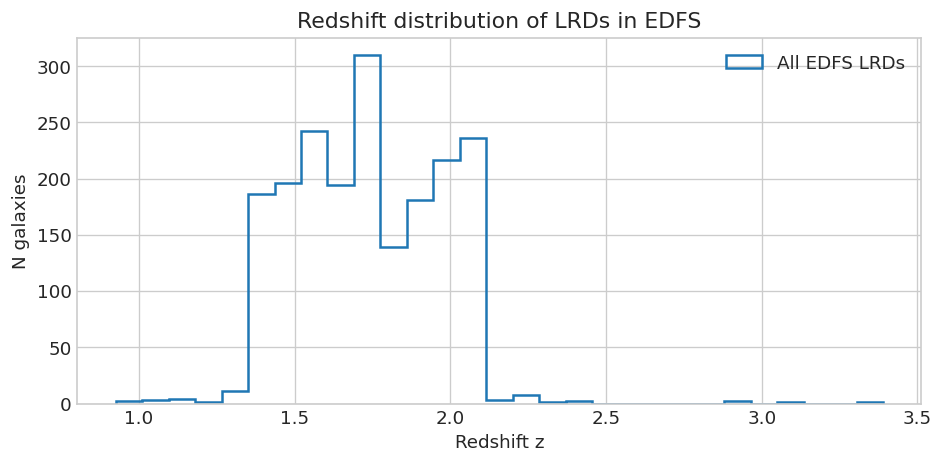

z range: 0.93 – 3.39
z mean : 1.74 ± 0.23


In [10]:
z_all  = np.asarray(table_edfs[cols["redshift"]])
irac_fp_edfs = np.asarray(table_edfs[cols["irac_footprint"]], dtype=bool)
z_fp   = z_all[irac_fp_edfs]

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(z_all.min(), z_all.max(), 30)
ax.hist(z_all, bins=bins, histtype="step", linewidth=1.5, label="All EDFS LRDs")
ax.set_xlabel("Redshift z")
ax.set_ylabel("N galaxies")
ax.set_title("Redshift distribution of LRDs in EDFS")
ax.legend()
plt.tight_layout()
plt.show()

print(f"z range: {z_all.min():.2f} – {z_all.max():.2f}")
print(f"z mean : {z_all.mean():.2f} ± {z_all.std():.2f}")

## 5. Sky distribution

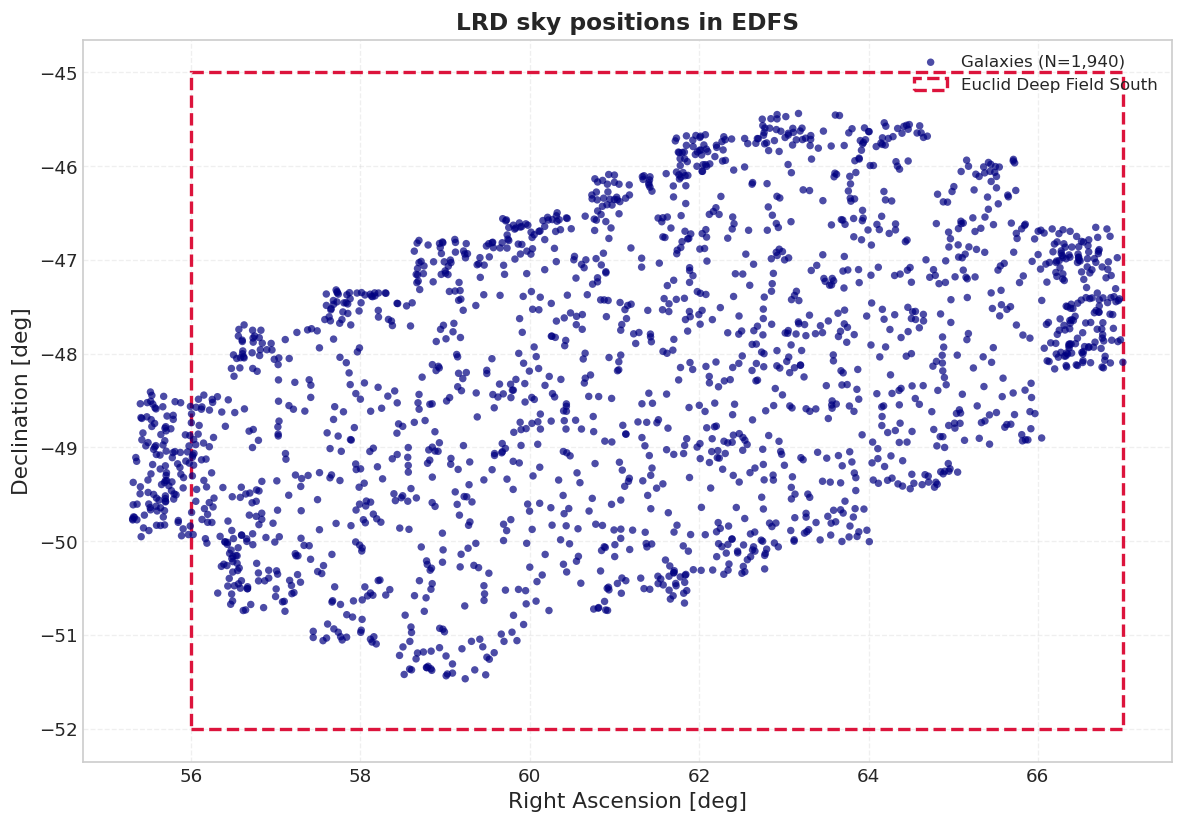

In [11]:
from src.plotting import plot_sky_distribution

ra_all  = np.asarray(table_edfs[cols["ra"]])
dec_all = np.asarray(table_edfs[cols["dec"]])

fig, ax = plot_sky_distribution(
    ra_all, dec_all,
    title="LRD sky positions in EDFS",
    show_edfs_box=True,
)
plt.show()

## 6. UV magnitude and UV slope distributions

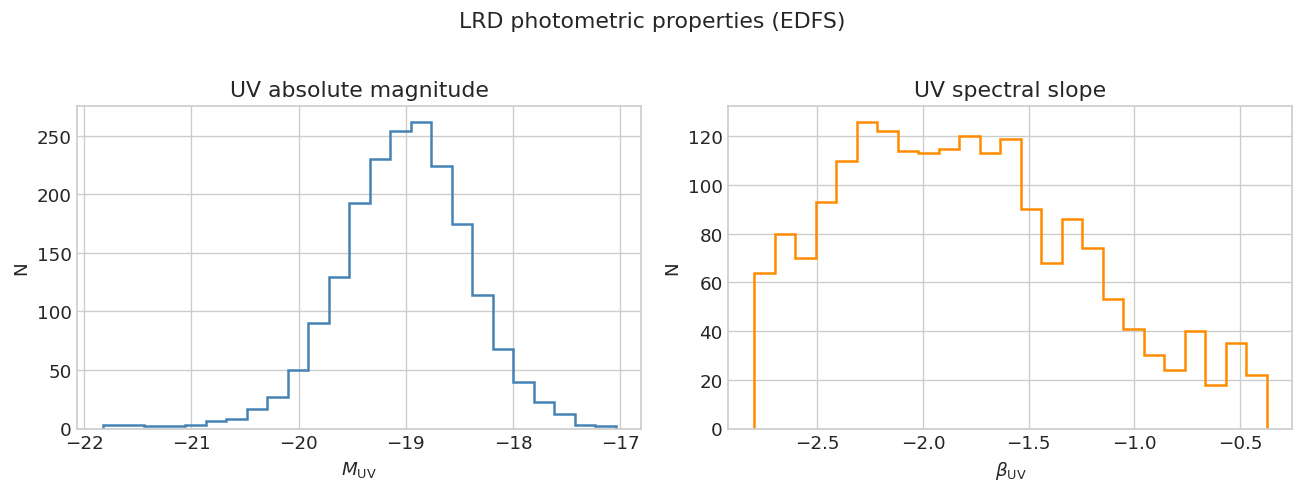

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

muv  = np.asarray(table_edfs["MUV"])
beta = np.asarray(table_edfs["beta_UV"])

axes[0].hist(muv[np.isfinite(muv)], bins=25, histtype="step", linewidth=1.5, color="steelblue")
axes[0].set_xlabel(r"$M_{\rm UV}$")
axes[0].set_ylabel("N")
axes[0].set_title("UV absolute magnitude")

axes[1].hist(beta[np.isfinite(beta)], bins=25, histtype="step", linewidth=1.5, color="darkorange")
axes[1].set_xlabel(r"$\beta_{\rm UV}$")
axes[1].set_ylabel("N")
axes[1].set_title("UV spectral slope")

plt.suptitle("LRD photometric properties (EDFS)", y=1.02)
plt.tight_layout()
plt.show()

## Summary

| Property | Value |
|---|---|
| Total LRDs in catalog | 3 341 |
| Within EDFS bounding box | see above |
| IRAC-footprint True | 1 509 |
| IRAC-detected True | 29 |
| Redshift range | z ~ 3–9 |

The catalog is ready for 2PACF analysis. Proceed to **02_mask_analysis** to validate
the Euclid survey mask.